In [1]:
! pip install pandas numpy missingno seaborn scikit-learn
import pandas as pd
import numpy as np
import missingno as msno
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn import datasets

pd.options.display.max_columns = 31
pd.options.display.max_rows = 20
pd.options.display.max_colwidth = 80
np.set_printoptions(precision=4, suppress=True)

In [2]:
filePath = 'combined.csv'
df = pd.read_csv(filePath)
df

,Div,Date,HomeTeam,AwayTeam,FTHG,FTAG,FTR,HTHG,HTAG,HTR,Referee,HS,AS,HST,AST,...,AY,HR,AR,IWH,IWD,IWA,WHH,WHD,WHA,Time,Attendance,HHW,AHW,HO,AO
0,E0,19/08/06,Arsenal,Aston Villa,1.0,1.0,D,0.0,0.0,D,G Poll,19.0,5.0,11.0,3.0,...,2.0,0.0,0.0,1.30,4.40,8.50,1.28,4.50,8.00,NaN,NaN,NaN,NaN,NaN,NaN
1,E0,19/08/06,Bolton,Tottenham,2.0,0.0,H,2.0,0.0,H,P Dowd,8.0,9.0,6.0,6.0,...,1.0,0.0,0.0,2.50,3.10,2.60,2.60,3.10,2.40,NaN,NaN,NaN,NaN,NaN,NaN
2,E0,19/08/06,Everton,Watford,2.0,1.0,H,1.0,0.0,H,P Walton,6.0,12.0,2.0,8.0,...,2.0,0.0,0.0,1.70,3.40,4.30,1.57,3.30,5.50,NaN,NaN,NaN,NaN,NaN,NaN
3,E0,19/08/06,Newcastle,Wigan,2.0,1.0,H,1.0,0.0,H,M Atkinson,9.0,14.0,8.0,9.0,...,2.0,0.0,0.0,1.70,3.40,4.30,1.72,3.20,4.33,NaN,NaN,NaN,NaN,NaN,NaN
4,E0,19/08/06,Portsmouth,Blackburn,3.0,0.0,H,1.0,0.0,H,A Wiley,21.0,9.0,16.0,7.0,...,1.0,0.0,2.0,2.50,3.10,2.60,2.20,3.10,2.87,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12576,E0,28/05/2023,Everton,Bournemouth,1.0,0.0,H,0.0,0.0,D,S Attwell,13.0,7.0,6.0,2.0,...,3.0,0.0,0.0,1.45,4.60,7.25,1.36,4.20,6.50,16:30,NaN,NaN,NaN,NaN,NaN
12577,E0,28/05/2023,Leeds,Tottenham,1.0,4.0,A,0.0,1.0,A,A Taylor,19.0,11.0,2.0,7.0,...,0.0,0.0,0.0,2.65,3.80,2.45,2.60,3.50,2.20,16:30,NaN,NaN,NaN,NaN,NaN
12578,E0,28/05/2023,Leicester,West Ham,2.0,1.0,H,1.0,0.0,H,S Hooper,13.0,16.0,4.0,3.0,...,1.0,0.0,0.0,1.95,3.85,3.60,1.85,3.60,3.30,16:30,NaN,NaN,NaN,NaN,NaN
12579,E0,28/05/2023,Man United,Fulham,2.0,1.0,H,1.0,1.0,D,R Jones,21.0,10.0,8.0,3.0,...,2.0,0.0,0.0,1.53,4.50,5.75,1.44,4.20,5.50,16:30,NaN,NaN,NaN,NaN,NaN


In [3]:
columnsToDrop = ['Time', 'Attendance', 'HHW', 'AHW', 'HO', 'AO']
df = df.drop(columns=columnsToDrop)
df

,Div,Date,HomeTeam,AwayTeam,FTHG,FTAG,FTR,HTHG,HTAG,HTR,Referee,HS,AS,HST,AST,HC,AC,HF,AF,HY,AY,HR,AR,IWH,IWD,IWA,WHH,WHD,WHA
0,E0,19/08/06,Arsenal,Aston Villa,1.0,1.0,D,0.0,0.0,D,G Poll,19.0,5.0,11.0,3.0,18.0,1.0,10.0,19.0,1.0,2.0,0.0,0.0,1.30,4.40,8.50,1.28,4.50,8.00
1,E0,19/08/06,Bolton,Tottenham,2.0,0.0,H,2.0,0.0,H,P Dowd,8.0,9.0,6.0,6.0,6.0,3.0,19.0,22.0,0.0,1.0,0.0,0.0,2.50,3.10,2.60,2.60,3.10,2.40
2,E0,19/08/06,Everton,Watford,2.0,1.0,H,1.0,0.0,H,P Walton,6.0,12.0,2.0,8.0,0.0,6.0,12.0,13.0,2.0,2.0,0.0,0.0,1.70,3.40,4.30,1.57,3.30,5.50
3,E0,19/08/06,Newcastle,Wigan,2.0,1.0,H,1.0,0.0,H,M Atkinson,9.0,14.0,8.0,9.0,4.0,11.0,17.0,20.0,1.0,2.0,0.0,0.0,1.70,3.40,4.30,1.72,3.20,4.33
4,E0,19/08/06,Portsmouth,Blackburn,3.0,0.0,H,1.0,0.0,H,A Wiley,21.0,9.0,16.0,7.0,6.0,2.0,20.0,17.0,2.0,1.0,0.0,2.0,2.50,3.10,2.60,2.20,3.10,2.87
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12576,E0,28/05/2023,Everton,Bournemouth,1.0,0.0,H,0.0,0.0,D,S Attwell,13.0,7.0,6.0,2.0,9.0,3.0,11.0,12.0,1.0,3.0,0.0,0.0,1.45,4.60,7.25,1.36,4.20,6.50
12577,E0,28/05/2023,Leeds,Tottenham,1.0,4.0,A,0.0,1.0,A,A Taylor,19.0,11.0,2.0,7.0,12.0,3.0,7.0,5.0,3.0,0.0,0.0,0.0,2.65,3.80,2.45,2.60,3.50,2.20
12578,E0,28/05/2023,Leicester,West Ham,2.0,1.0,H,1.0,0.0,H,S Hooper,13.0,16.0,4.0,3.0,3.0,5.0,8.0,10.0,1.0,1.0,0.0,0.0,1.95,3.85,3.60,1.85,3.60,3.30
12579,E0,28/05/2023,Man United,Fulham,2.0,1.0,H,1.0,1.0,D,R Jones,21.0,10.0,8.0,3.0,5.0,4.0,14.0,10.0,1.0,2.0,0.0,0.0,1.53,4.50,5.75,1.44,4.20,5.50


In [4]:
# Convert the 'Date' column to datetime format, coercing errors to NaT
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')
df = df.sort_values(by='Date')
df

/var/folders/tk/jl3yfcz52s9020z4_8dbfkvw0000gn/T/ipykernel_99344/3882893573.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Date'] = pd.to_datetime(df['Date'], errors='coerce')


,Div,Date,HomeTeam,AwayTeam,FTHG,FTAG,FTR,HTHG,HTAG,HTR,Referee,HS,AS,HST,AST,HC,AC,HF,AF,HY,AY,HR,AR,IWH,IWD,IWA,WHH,WHD,WHA
9141,E0,1993-01-09,QPR,Sheffield United,2.0,1.0,H,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9138,E0,1993-01-09,Blackburn,Arsenal,1.0,1.0,D,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9139,E0,1993-01-09,Coventry,Liverpool,1.0,0.0,H,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9140,E0,1993-01-09,Man United,West Ham,3.0,0.0,H,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9142,E0,1993-01-09,Sheffield Weds,Norwich,3.0,3.0,D,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9626,NaN,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9627,NaN,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9628,NaN,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9629,NaN,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [5]:
# Define the start date for filtering
start_date = pd.Timestamp('2000-08-18')

# Filter the DataFrame to keep only the rows from the start date to the present
df = df[df['Date'] >= start_date]
df

,Div,Date,HomeTeam,AwayTeam,FTHG,FTAG,FTR,HTHG,HTAG,HTR,Referee,HS,AS,HST,AST,HC,AC,HF,AF,HY,AY,HR,AR,IWH,IWD,IWA,WHH,WHD,WHA
3630,E0,2000-08-19,Tottenham,Ipswich,3.0,1.0,H,2.0,1.0,H,Alan Wiley,20.0,15.0,6.0,5.0,3.0,4.0,14.0,13.0,0.0,0.0,0.0,0.0,1.50,3.4,4.7,1.44,3.60,6.50
3629,E0,2000-08-19,Sunderland,Arsenal,1.0,0.0,H,0.0,0.0,D,Steve Dunn,8.0,14.0,2.0,7.0,2.0,9.0,10.0,21.0,3.0,1.0,0.0,1.0,2.90,2.9,2.1,3.75,3.00,1.90
3628,E0,2000-08-19,Liverpool,Bradford,1.0,0.0,H,0.0,0.0,D,Paul Durkin,16.0,3.0,10.0,2.0,6.0,1.0,8.0,8.0,1.0,1.0,0.0,0.0,1.25,4.3,8.0,1.33,4.00,8.00
3627,E0,2000-08-19,Leicester,Aston Villa,0.0,0.0,D,0.0,0.0,D,Mike Riley,5.0,5.0,4.0,3.0,5.0,4.0,12.0,12.0,2.0,3.0,0.0,0.0,2.30,2.9,2.5,2.40,3.25,2.50
3626,E0,2000-08-19,Leeds,Everton,2.0,0.0,H,2.0,0.0,H,Dermot Gallagher,17.0,12.0,8.0,6.0,6.0,4.0,21.0,20.0,1.0,3.0,0.0,0.0,1.55,3.3,4.5,1.61,3.50,4.50
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1118,E0,2024-11-05,Bournemouth,Brentford,1.0,2.0,A,0.0,0.0,D,M Donohue,13.0,11.0,4.0,5.0,3.0,8.0,16.0,12.0,2.0,2.0,0.0,0.0,NaN,NaN,NaN,1.95,4.00,3.40
1117,E0,2024-11-05,Fulham,Man City,0.0,4.0,A,0.0,1.0,A,A Taylor,1.0,16.0,1.0,9.0,1.0,7.0,9.0,6.0,1.0,0.0,1.0,0.0,NaN,NaN,NaN,12.00,7.00,1.22
958,E0,2024-12-01,Burnley,Luton,1.0,1.0,D,1.0,0.0,H,T Harrington,13.0,14.0,7.0,5.0,2.0,8.0,7.0,12.0,1.0,0.0,0.0,0.0,NaN,NaN,NaN,1.91,3.60,3.60
997,E0,2024-12-02,Crystal Palace,Chelsea,1.0,3.0,A,1.0,0.0,H,M Oliver,13.0,14.0,4.0,5.0,1.0,7.0,14.0,7.0,2.0,2.0,0.0,0.0,NaN,NaN,NaN,3.90,3.70,1.83


In [6]:
# Extract year, month, and day of the week
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['DayOfWeek'] = df['Date'].dt.dayofweek

# Drop the original 'Date' column if it's no longer needed
df.drop(columns=['Date' , 'Referee', 'Div'], inplace=True)

df

/var/folders/tk/jl3yfcz52s9020z4_8dbfkvw0000gn/T/ipykernel_99344/4277185833.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Year'] = df['Date'].dt.year
/var/folders/tk/jl3yfcz52s9020z4_8dbfkvw0000gn/T/ipykernel_99344/4277185833.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Month'] = df['Date'].dt.month
/var/folders/tk/jl3yfcz52s9020z4_8dbfkvw0000gn/T/ipykernel_99344/4277185833.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[r

,HomeTeam,AwayTeam,FTHG,FTAG,FTR,HTHG,HTAG,HTR,HS,AS,HST,AST,HC,AC,HF,AF,HY,AY,HR,AR,IWH,IWD,IWA,WHH,WHD,WHA,Year,Month,DayOfWeek
3630,Tottenham,Ipswich,3.0,1.0,H,2.0,1.0,H,20.0,15.0,6.0,5.0,3.0,4.0,14.0,13.0,0.0,0.0,0.0,0.0,1.50,3.4,4.7,1.44,3.60,6.50,2000,8,5
3629,Sunderland,Arsenal,1.0,0.0,H,0.0,0.0,D,8.0,14.0,2.0,7.0,2.0,9.0,10.0,21.0,3.0,1.0,0.0,1.0,2.90,2.9,2.1,3.75,3.00,1.90,2000,8,5
3628,Liverpool,Bradford,1.0,0.0,H,0.0,0.0,D,16.0,3.0,10.0,2.0,6.0,1.0,8.0,8.0,1.0,1.0,0.0,0.0,1.25,4.3,8.0,1.33,4.00,8.00,2000,8,5
3627,Leicester,Aston Villa,0.0,0.0,D,0.0,0.0,D,5.0,5.0,4.0,3.0,5.0,4.0,12.0,12.0,2.0,3.0,0.0,0.0,2.30,2.9,2.5,2.40,3.25,2.50,2000,8,5
3626,Leeds,Everton,2.0,0.0,H,2.0,0.0,H,17.0,12.0,8.0,6.0,6.0,4.0,21.0,20.0,1.0,3.0,0.0,0.0,1.55,3.3,4.5,1.61,3.50,4.50,2000,8,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1118,Bournemouth,Brentford,1.0,2.0,A,0.0,0.0,D,13.0,11.0,4.0,5.0,3.0,8.0,16.0,12.0,2.0,2.0,0.0,0.0,NaN,NaN,NaN,1.95,4.00,3.40,2024,11,1
1117,Fulham,Man City,0.0,4.0,A,0.0,1.0,A,1.0,16.0,1.0,9.0,1.0,7.0,9.0,6.0,1.0,0.0,1.0,0.0,NaN,NaN,NaN,12.00,7.00,1.22,2024,11,1
958,Burnley,Luton,1.0,1.0,D,1.0,0.0,H,13.0,14.0,7.0,5.0,2.0,8.0,7.0,12.0,1.0,0.0,0.0,0.0,NaN,NaN,NaN,1.91,3.60,3.60,2024,12,6
997,Crystal Palace,Chelsea,1.0,3.0,A,1.0,0.0,H,13.0,14.0,4.0,5.0,1.0,7.0,14.0,7.0,2.0,2.0,0.0,0.0,NaN,NaN,NaN,3.90,3.70,1.83,2024,12,0


In [7]:
df = df.dropna()
df

,HomeTeam,AwayTeam,FTHG,FTAG,FTR,HTHG,HTAG,HTR,HS,AS,HST,AST,HC,AC,HF,AF,HY,AY,HR,AR,IWH,IWD,IWA,WHH,WHD,WHA,Year,Month,DayOfWeek
3630,Tottenham,Ipswich,3.0,1.0,H,2.0,1.0,H,20.0,15.0,6.0,5.0,3.0,4.0,14.0,13.0,0.0,0.0,0.0,0.0,1.50,3.4,4.70,1.44,3.60,6.50,2000,8,5
3629,Sunderland,Arsenal,1.0,0.0,H,0.0,0.0,D,8.0,14.0,2.0,7.0,2.0,9.0,10.0,21.0,3.0,1.0,0.0,1.0,2.90,2.9,2.10,3.75,3.00,1.90,2000,8,5
3628,Liverpool,Bradford,1.0,0.0,H,0.0,0.0,D,16.0,3.0,10.0,2.0,6.0,1.0,8.0,8.0,1.0,1.0,0.0,0.0,1.25,4.3,8.00,1.33,4.00,8.00,2000,8,5
3627,Leicester,Aston Villa,0.0,0.0,D,0.0,0.0,D,5.0,5.0,4.0,3.0,5.0,4.0,12.0,12.0,2.0,3.0,0.0,0.0,2.30,2.9,2.50,2.40,3.25,2.50,2000,8,5
3626,Leeds,Everton,2.0,0.0,H,2.0,0.0,H,17.0,12.0,8.0,6.0,6.0,4.0,21.0,20.0,1.0,3.0,0.0,0.0,1.55,3.3,4.50,1.61,3.50,4.50,2000,8,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
951,Man City,Sheffield United,2.0,0.0,H,1.0,0.0,H,18.0,4.0,4.0,2.0,12.0,2.0,5.0,6.0,1.0,1.0,0.0,0.0,1.08,11.0,26.00,1.04,12.00,29.00,2023,12,5
955,Tottenham,Bournemouth,3.0,1.0,H,1.0,0.0,H,12.0,24.0,6.0,4.0,4.0,13.0,9.0,18.0,3.0,3.0,0.0,0.0,1.80,4.3,3.90,1.70,4.20,4.00,2023,12,6
954,Fulham,Arsenal,2.0,1.0,H,1.0,1.0,D,15.0,13.0,4.0,3.0,5.0,4.0,11.0,10.0,4.0,1.0,0.0,0.0,5.50,4.3,1.57,5.50,4.20,1.53,2023,12,6
956,Liverpool,Newcastle,4.0,2.0,H,0.0,0.0,D,34.0,5.0,15.0,3.0,7.0,3.0,16.0,15.0,3.0,5.0,0.0,0.0,1.47,4.9,6.00,1.40,4.80,6.50,2024,1,0


In [8]:
# Add a new column 'TotalGoals' that sums 'FTHG' and 'FTAG'
df['TotalGoals'] = df['FTHG'] + df['FTAG']

# Add a new column 'GoalsOver2_5' based on the value of 'TotalGoals'
df['GoalsOver2_5'] = df['TotalGoals'].apply(lambda x: 1 if x >= 2.5 else 0)

# Display the updated DataFrame
df

/var/folders/tk/jl3yfcz52s9020z4_8dbfkvw0000gn/T/ipykernel_99344/3295516149.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['TotalGoals'] = df['FTHG'] + df['FTAG']
/var/folders/tk/jl3yfcz52s9020z4_8dbfkvw0000gn/T/ipykernel_99344/3295516149.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['GoalsOver2_5'] = df['TotalGoals'].apply(lambda x: 1 if x >= 2.5 else 0)


,HomeTeam,AwayTeam,FTHG,FTAG,FTR,HTHG,HTAG,HTR,HS,AS,HST,AST,HC,AC,HF,AF,HY,AY,HR,AR,IWH,IWD,IWA,WHH,WHD,WHA,Year,Month,DayOfWeek,TotalGoals,GoalsOver2_5
3630,Tottenham,Ipswich,3.0,1.0,H,2.0,1.0,H,20.0,15.0,6.0,5.0,3.0,4.0,14.0,13.0,0.0,0.0,0.0,0.0,1.50,3.4,4.70,1.44,3.60,6.50,2000,8,5,4.0,1
3629,Sunderland,Arsenal,1.0,0.0,H,0.0,0.0,D,8.0,14.0,2.0,7.0,2.0,9.0,10.0,21.0,3.0,1.0,0.0,1.0,2.90,2.9,2.10,3.75,3.00,1.90,2000,8,5,1.0,0
3628,Liverpool,Bradford,1.0,0.0,H,0.0,0.0,D,16.0,3.0,10.0,2.0,6.0,1.0,8.0,8.0,1.0,1.0,0.0,0.0,1.25,4.3,8.00,1.33,4.00,8.00,2000,8,5,1.0,0
3627,Leicester,Aston Villa,0.0,0.0,D,0.0,0.0,D,5.0,5.0,4.0,3.0,5.0,4.0,12.0,12.0,2.0,3.0,0.0,0.0,2.30,2.9,2.50,2.40,3.25,2.50,2000,8,5,0.0,0
3626,Leeds,Everton,2.0,0.0,H,2.0,0.0,H,17.0,12.0,8.0,6.0,6.0,4.0,21.0,20.0,1.0,3.0,0.0,0.0,1.55,3.3,4.50,1.61,3.50,4.50,2000,8,5,2.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
951,Man City,Sheffield United,2.0,0.0,H,1.0,0.0,H,18.0,4.0,4.0,2.0,12.0,2.0,5.0,6.0,1.0,1.0,0.0,0.0,1.08,11.0,26.00,1.04,12.00,29.00,2023,12,5,2.0,0
955,Tottenham,Bournemouth,3.0,1.0,H,1.0,0.0,H,12.0,24.0,6.0,4.0,4.0,13.0,9.0,18.0,3.0,3.0,0.0,0.0,1.80,4.3,3.90,1.70,4.20,4.00,2023,12,6,4.0,1
954,Fulham,Arsenal,2.0,1.0,H,1.0,1.0,D,15.0,13.0,4.0,3.0,5.0,4.0,11.0,10.0,4.0,1.0,0.0,0.0,5.50,4.3,1.57,5.50,4.20,1.53,2023,12,6,3.0,1
956,Liverpool,Newcastle,4.0,2.0,H,0.0,0.0,D,34.0,5.0,15.0,3.0,7.0,3.0,16.0,15.0,3.0,5.0,0.0,0.0,1.47,4.9,6.00,1.40,4.80,6.50,2024,1,0,6.0,1


In [9]:
df.dtypes

HomeTeam         object
AwayTeam         object
FTHG            float64
FTAG            float64
FTR              object
                 ...   
Year              int32
Month             int32
DayOfWeek         int32
TotalGoals      float64
GoalsOver2_5      int64
Length: 31, dtype: object

In [10]:
df = pd.get_dummies(df, columns=['HomeTeam', 'AwayTeam', 'FTR', 'HTR'])
df

,FTHG,FTAG,HTHG,HTAG,HS,AS,HST,AST,HC,AC,HF,AF,HY,AY,HR,...,AwayTeam_Stoke,AwayTeam_Sunderland,AwayTeam_Swansea,AwayTeam_Tottenham,AwayTeam_Watford,AwayTeam_West Brom,AwayTeam_West Ham,AwayTeam_Wigan,AwayTeam_Wolves,FTR_A,FTR_D,FTR_H,HTR_A,HTR_D,HTR_H
3630,3.0,1.0,2.0,1.0,20.0,15.0,6.0,5.0,3.0,4.0,14.0,13.0,0.0,0.0,0.0,...,False,False,False,False,False,False,False,False,False,False,False,True,False,False,True
3629,1.0,0.0,0.0,0.0,8.0,14.0,2.0,7.0,2.0,9.0,10.0,21.0,3.0,1.0,0.0,...,False,False,False,False,False,False,False,False,False,False,False,True,False,True,False
3628,1.0,0.0,0.0,0.0,16.0,3.0,10.0,2.0,6.0,1.0,8.0,8.0,1.0,1.0,0.0,...,False,False,False,False,False,False,False,False,False,False,False,True,False,True,False
3627,0.0,0.0,0.0,0.0,5.0,5.0,4.0,3.0,5.0,4.0,12.0,12.0,2.0,3.0,0.0,...,False,False,False,False,False,False,False,False,False,False,True,False,False,True,False
3626,2.0,0.0,2.0,0.0,17.0,12.0,8.0,6.0,6.0,4.0,21.0,20.0,1.0,3.0,0.0,...,False,False,False,False,False,False,False,False,False,False,False,True,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
951,2.0,0.0,1.0,0.0,18.0,4.0,4.0,2.0,12.0,2.0,5.0,6.0,1.0,1.0,0.0,...,False,False,False,False,False,False,False,False,False,False,False,True,False,False,True
955,3.0,1.0,1.0,0.0,12.0,24.0,6.0,4.0,4.0,13.0,9.0,18.0,3.0,3.0,0.0,...,False,False,False,False,False,False,False,False,False,False,False,True,False,False,True
954,2.0,1.0,1.0,1.0,15.0,13.0,4.0,3.0,5.0,4.0,11.0,10.0,4.0,1.0,0.0,...,False,False,False,False,False,False,False,False,False,False,False,True,False,True,False
956,4.0,2.0,0.0,0.0,34.0,5.0,15.0,3.0,7.0,3.0,16.0,15.0,3.0,5.0,0.0,...,False,False,False,False,False,False,False,False,False,False,False,True,False,True,False


In [11]:
boolean_columns = df.select_dtypes(include=['bool']).columns
df[boolean_columns] = df[boolean_columns].astype(int)
df

,FTHG,FTAG,HTHG,HTAG,HS,AS,HST,AST,HC,AC,HF,AF,HY,AY,HR,...,AwayTeam_Stoke,AwayTeam_Sunderland,AwayTeam_Swansea,AwayTeam_Tottenham,AwayTeam_Watford,AwayTeam_West Brom,AwayTeam_West Ham,AwayTeam_Wigan,AwayTeam_Wolves,FTR_A,FTR_D,FTR_H,HTR_A,HTR_D,HTR_H
3630,3.0,1.0,2.0,1.0,20.0,15.0,6.0,5.0,3.0,4.0,14.0,13.0,0.0,0.0,0.0,...,0,0,0,0,0,0,0,0,0,0,0,1,0,0,1
3629,1.0,0.0,0.0,0.0,8.0,14.0,2.0,7.0,2.0,9.0,10.0,21.0,3.0,1.0,0.0,...,0,0,0,0,0,0,0,0,0,0,0,1,0,1,0
3628,1.0,0.0,0.0,0.0,16.0,3.0,10.0,2.0,6.0,1.0,8.0,8.0,1.0,1.0,0.0,...,0,0,0,0,0,0,0,0,0,0,0,1,0,1,0
3627,0.0,0.0,0.0,0.0,5.0,5.0,4.0,3.0,5.0,4.0,12.0,12.0,2.0,3.0,0.0,...,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0
3626,2.0,0.0,2.0,0.0,17.0,12.0,8.0,6.0,6.0,4.0,21.0,20.0,1.0,3.0,0.0,...,0,0,0,0,0,0,0,0,0,0,0,1,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
951,2.0,0.0,1.0,0.0,18.0,4.0,4.0,2.0,12.0,2.0,5.0,6.0,1.0,1.0,0.0,...,0,0,0,0,0,0,0,0,0,0,0,1,0,0,1
955,3.0,1.0,1.0,0.0,12.0,24.0,6.0,4.0,4.0,13.0,9.0,18.0,3.0,3.0,0.0,...,0,0,0,0,0,0,0,0,0,0,0,1,0,0,1
954,2.0,1.0,1.0,1.0,15.0,13.0,4.0,3.0,5.0,4.0,11.0,10.0,4.0,1.0,0.0,...,0,0,0,0,0,0,0,0,0,0,0,1,0,1,0
956,4.0,2.0,0.0,0.0,34.0,5.0,15.0,3.0,7.0,3.0,16.0,15.0,3.0,5.0,0.0,...,0,0,0,0,0,0,0,0,0,0,0,1,0,1,0


In [12]:
# Set the style of the visualizations
sns.set_style("whitegrid")

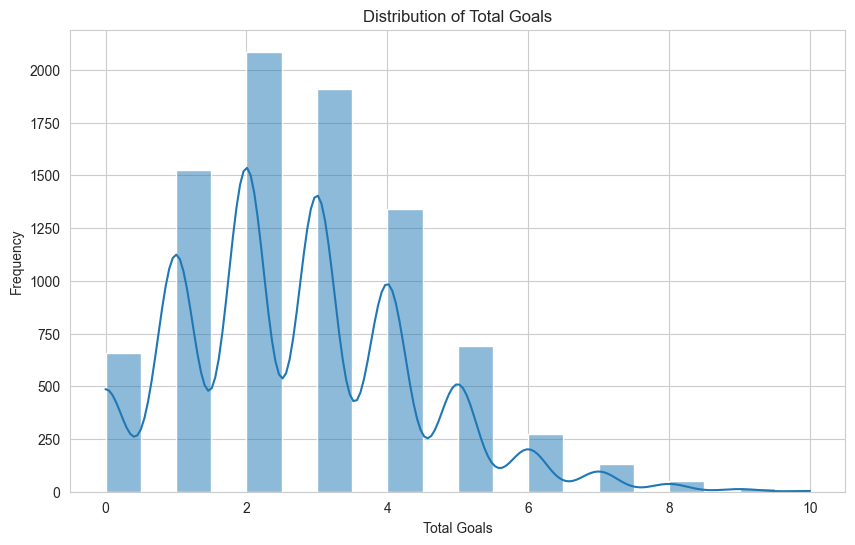

In [13]:
# 1. Distribution of Total Goals
plt.figure(figsize=(10, 6))
sns.histplot(df['TotalGoals'], bins=20, kde=True)
plt.title('Distribution of Total Goals')
plt.xlabel('Total Goals')
plt.ylabel('Frequency')
plt.show()

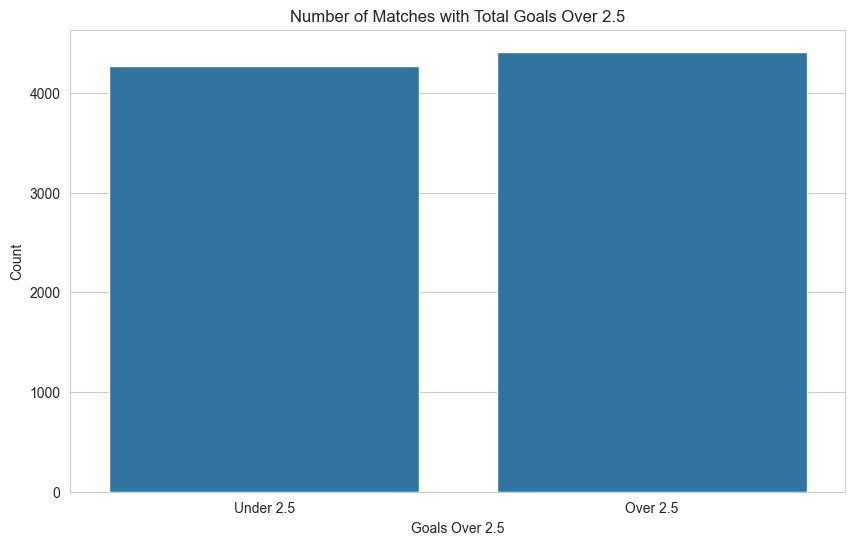

In [15]:
# 2. Goals Over 2.5
plt.figure(figsize=(10, 6))
sns.countplot(x='GoalsOver2_5', data=df)
plt.title('Number of Matches with Total Goals Over 2.5')
plt.xlabel('Goals Over 2.5')
plt.ylabel('Count')
plt.xticks([0, 1], ['Under 2.5', 'Over 2.5'])
plt.show()

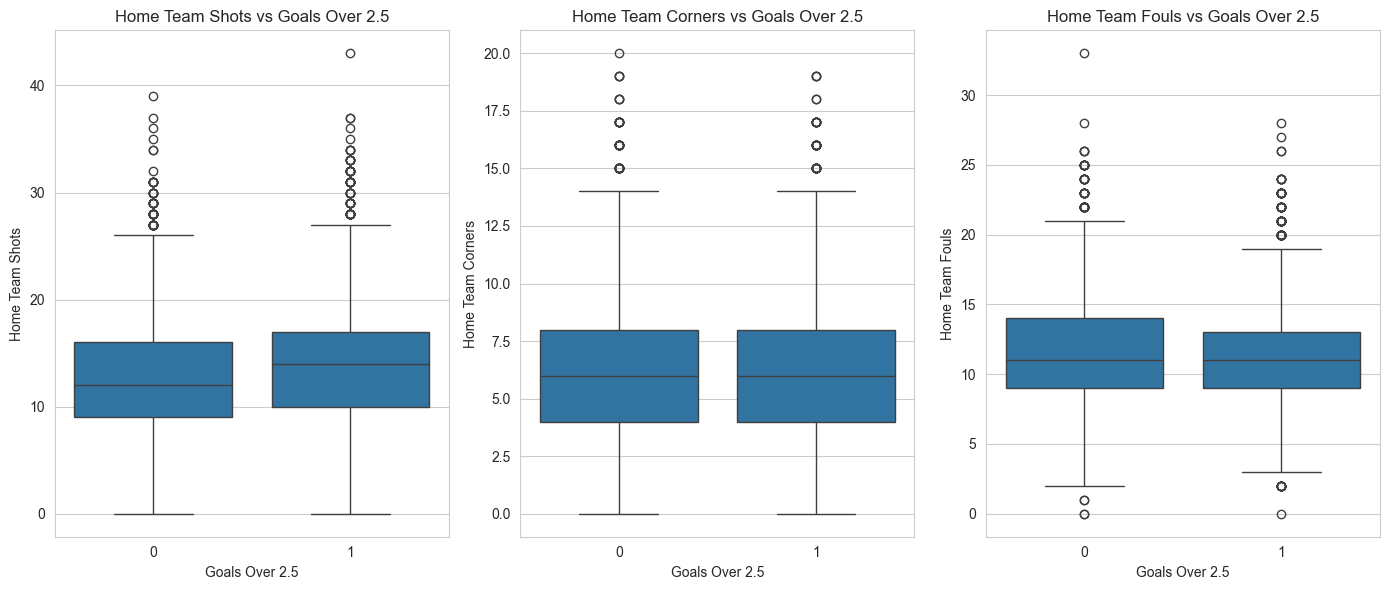

In [16]:
# 3. Box Plot for Shots, Corners, and Fouls
plt.figure(figsize=(14, 6))

# Home Team Shots
plt.subplot(1, 3, 1)
sns.boxplot(x='GoalsOver2_5', y='HS', data=df)
plt.title('Home Team Shots vs Goals Over 2.5')
plt.xlabel('Goals Over 2.5')
plt.ylabel('Home Team Shots')

# Home Team Corners
plt.subplot(1, 3, 2)
sns.boxplot(x='GoalsOver2_5', y='HC', data=df)
plt.title('Home Team Corners vs Goals Over 2.5')
plt.xlabel('Goals Over 2.5')
plt.ylabel('Home Team Corners')

# Home Team Fouls
plt.subplot(1, 3, 3)
sns.boxplot(x='GoalsOver2_5', y='HF', data=df)
plt.title('Home Team Fouls vs Goals Over 2.5')
plt.xlabel('Goals Over 2.5')
plt.ylabel('Home Team Fouls')

plt.tight_layout()
plt.show()

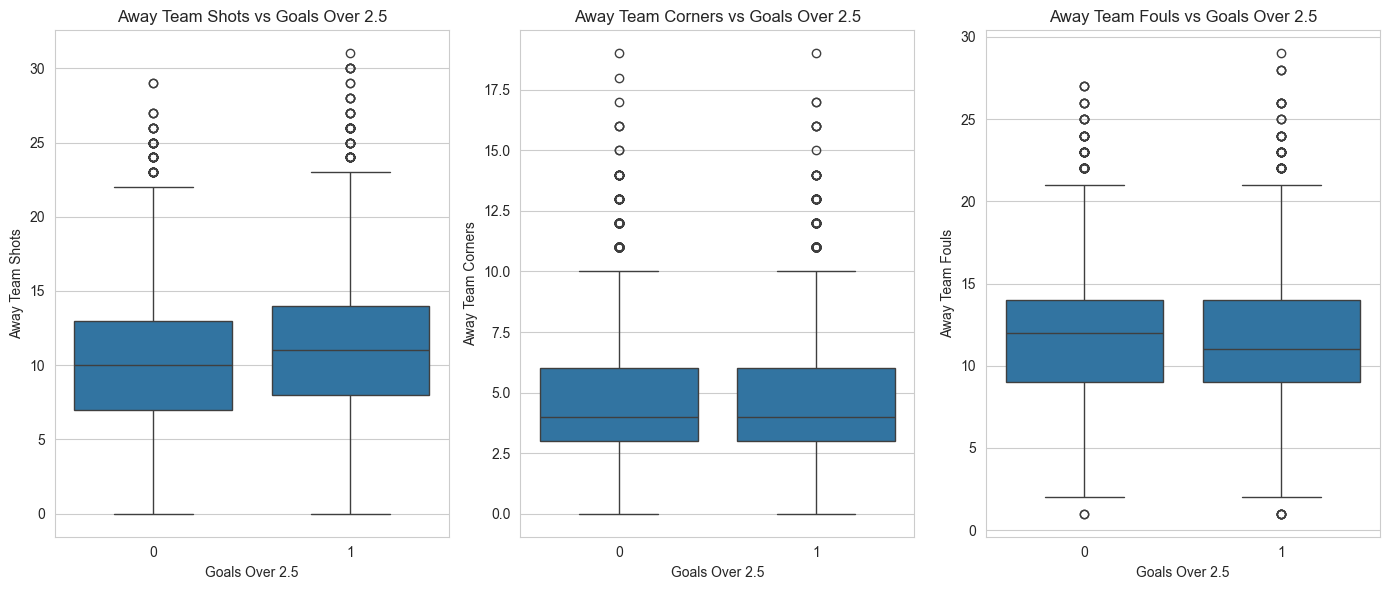

In [17]:
plt.figure(figsize=(14, 6))

# Away Team Shots
plt.subplot(1, 3, 1)
sns.boxplot(x='GoalsOver2_5', y='AS', data=df)
plt.title('Away Team Shots vs Goals Over 2.5')
plt.xlabel('Goals Over 2.5')
plt.ylabel('Away Team Shots')

# Away Team Corners
plt.subplot(1, 3, 2)
sns.boxplot(x='GoalsOver2_5', y='AC', data=df)
plt.title('Away Team Corners vs Goals Over 2.5')
plt.xlabel('Goals Over 2.5')
plt.ylabel('Away Team Corners')

# Away Team Fouls
plt.subplot(1, 3, 3)
sns.boxplot(x='GoalsOver2_5', y='AF', data=df)
plt.title('Away Team Fouls vs Goals Over 2.5')
plt.xlabel('Goals Over 2.5')
plt.ylabel('Away Team Fouls')

plt.tight_layout()
plt.show()

In [19]:
# Save the DataFrame to a CSV file
df.to_csv('cleaned_data.csv', index=False)